<a href="https://colab.research.google.com/github/khwela/unsupervised-machine-learning/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Unsupervised Learning Assessment***

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
dataset = pd.read_csv('Wholesale customers data.csv')
x = dataset.iloc[:,1:].values
y = dataset.iloc[:,-1].values

Handling Missing Data

In [8]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(x[:,1:6])
x[:,1:6] = imputer.transform(x[:,1:6])

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [10]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(  x, y, test_size=0.2, random_state=1)



Feature Scalling

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train[:, 3:] = sc.fit_transform(x_train[:, 3:])
x_test[:, 3:] = sc.transform(x_test[:, 3:])

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)
x.shape

(440, 9)

In [13]:
from sklearn.decomposition import PCA
pca = PCA(0.95)
x_pca = pca.fit_transform(x)
x_pca.shape

(440, 4)

In [14]:
x_train_pca, x_test_pca, y_train, y_test = train_test_split(x_pca,y,test_size=0.2,random_state=30)

In [15]:
print(x_test_pca.shape)

(88, 4)


In [16]:
model = LogisticRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.0

In [17]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
x_pca.shape
x_pca

array([[ 6.50022123e+02,  1.58551909e+03],
       [-4.42680498e+03,  4.04245151e+03],
       [-4.84199871e+03,  2.57876218e+03],
       [ 9.90346438e+02, -6.27980600e+03],
       [ 1.06579987e+04, -2.15972582e+03],
       [-2.76596159e+03, -9.59870727e+02],
       [-7.15550891e+02, -2.01300227e+03],
       [-4.47458367e+03,  1.42949697e+03],
       [-6.71209540e+03, -2.20590916e+03],
       [-4.82363435e+03,  1.34805592e+04],
       [-7.97482898e+03,  5.71121893e+03],
       [ 3.63937800e+01, -6.03789641e+03],
       [ 1.99402021e+04,  4.59128648e+03],
       [ 9.39669558e+03,  5.91315704e+03],
       [ 1.26603704e+04,  4.54194544e+03],
       [-2.99772590e+03, -6.09387930e+03],
       [-1.05895236e+04,  6.58421594e+03],
       [-6.36709518e+03, -3.68071267e+03],
       [ 6.62382534e+03,  1.25471953e+03],
       [-4.86153157e+03, -2.25592266e+02],
       [ 4.79424416e+03, -3.98879936e+03],
       [-7.24486684e+03, -7.34772325e+03],
       [ 1.92992657e+04, -6.93681068e+03],
       [ 1.

In [18]:
pca.explained_variance_ratio_

array([0.45961362, 0.40517227])

In [19]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance

array([0.45961362, 0.86478588])

Plot Visualization

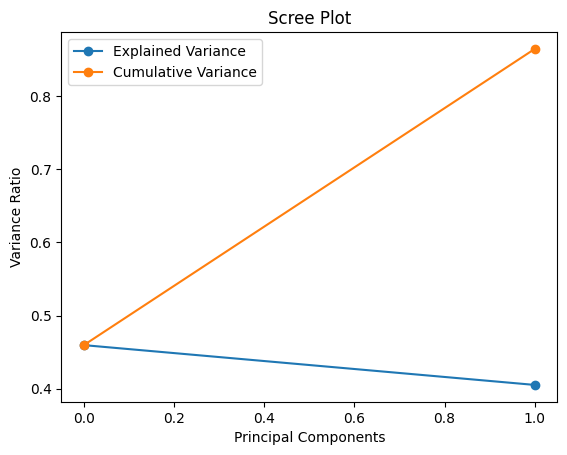

In [20]:
plt.figure()
explained_variance = pca.explained_variance_ratio_
plt.plot(explained_variance, marker='o', label="Explained Variance")
plt.plot(cumulative_variance, marker='o', label="Cumulative Variance")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.title("Scree Plot")
plt.legend()
plt.show()

KMeans

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt




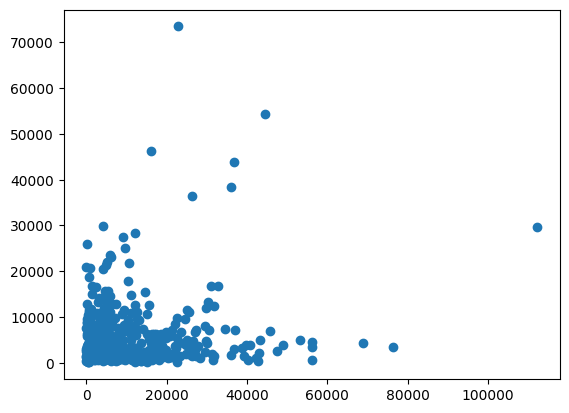

In [30]:
plt.scatter(dataset['Fresh'], dataset['Milk'])

In [39]:
km = KMeans(n_clusters=3)

In [33]:
y_predict = km.fit_predict(dataset[['Fresh','Milk']])
y_predict

array([0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0,
       2, 1, 2, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 2,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 2, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0,

In [38]:
dataset['Cluster'] = y_predict
dataset.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluter,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0,0
1,2,3,7057,9810,9568,1762,3293,1776,0,0
2,2,3,6353,8808,7684,2405,3516,7844,0,0
3,1,3,13265,1196,4221,6404,507,1788,0,0
4,2,3,22615,5410,7198,3915,1777,5185,2,2


In [47]:
y_predict = km.fit_predict(dataset[['Fresh','Milk']])
km.cluster_centers_

array([[0.24271247, 0.05471838],
       [0.05493189, 0.07428368],
       [0.37552418, 0.62621547]])

In [35]:
dataset1 = dataset[dataset['Cluter']==0]
dataset2 = dataset[dataset['Cluter']==1]
dataset3 = dataset[dataset['Cluter']==2]
dataset.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluter
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,2


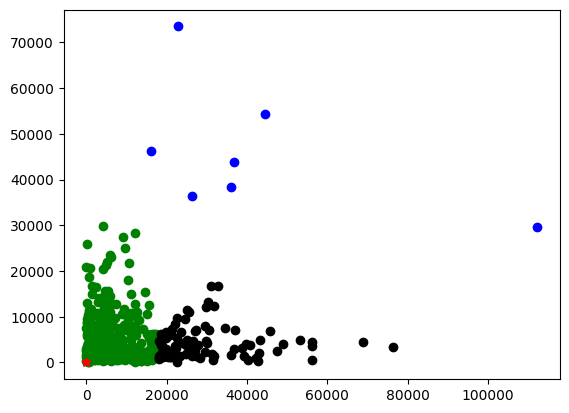

In [52]:
plt.scatter(dataset1['Fresh'], dataset1['Milk'] , color= 'green')
plt.scatter(dataset2['Fresh'], dataset2['Milk'] , color= 'blue')
plt.scatter(dataset3['Fresh'], dataset3['Milk'] , color= 'Black')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='red', marker = '*', label = 'centroid')

In [58]:
scaler = MinMaxScaler()
scaler.fit(dataset[['Fresh','Milk']])
dataset[['Fresh','Milk']] = scaler.transform(dataset[['Fresh','Milk']])

dataset

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluter,Cluster
0,2,3,0.112940,0.130727,0.081464,0.003106,2674,1338,0,0
1,2,3,0.062899,0.132824,0.103097,0.028548,3293,1776,0,0
2,2,3,0.056622,0.119181,0.082790,0.039116,3516,7844,0,0
3,1,3,0.118254,0.015536,0.045464,0.104842,507,1788,0,0
4,2,3,0.201626,0.072914,0.077552,0.063934,1777,5185,2,2
...,...,...,...,...,...,...,...,...,...,...
435,1,3,0.264829,0.163338,0.172715,0.215469,182,2204,2,2
436,1,3,0.349761,0.018736,0.008202,0.073713,93,2346,2,2
437,2,3,0.129543,0.210136,0.325943,0.006771,14841,1867,0,0
438,1,3,0.091727,0.026224,0.024025,0.016649,168,2125,0,0


In [55]:
k_rng = range(1,10)
sse = []
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(dataset[['Fresh','Milk']])
    sse.append(km.inertia_)

In [56]:
sse

[10.016382840859324,
 7.3330202968358345,
 4.370113972900014,
 3.4604675394672797,
 2.317222767940139,
 1.9090523702924544,
 1.7501074588594756,
 1.2693799129340873,
 1.1631102807834799]

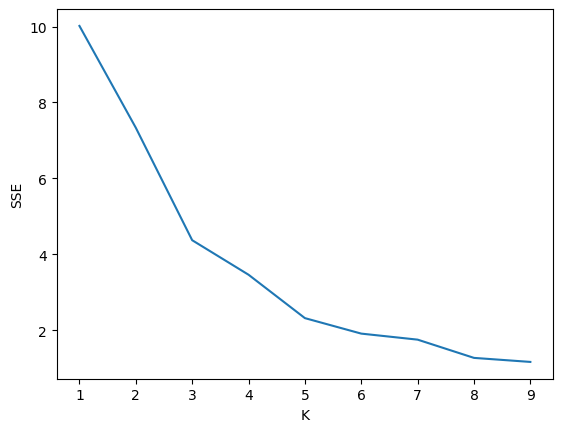

In [57]:
plt.xlabel('K')
plt.ylabel('SSE')
plt.plot(k_rng,sse)


The elbow plot shows a noticeable bend at k=3 where the decrease in inertia begins to slow down. The silhouette score is also relatively high at k=3 indicating well-separated clusters. Therefore, was selected as the optimal number of clusters for the dataset